# Customer Segmentation — RFM + KMeans
**AdventureWorks2022 | Notebook 1**

Goal: SQL analysis showed 61% of customers are one-and-done and the top decile drives 81.6% of revenue.
Here we segment all customers by **R**ecency / **F**requency / **M**onetary using KMeans,
so marketing can target each group differently. Segments are written back to SQL for Power BI.

Snapshot date: **2014-06-30** (last day in the data).

In [1]:
import pyodbc, pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings; warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

cn = pyodbc.connect(
    'Driver={ODBC Driver 18 for SQL Server};Server=.\\SQLEXPRESS;'
    'Database=AdventureWorks2022;Trusted_Connection=yes;TrustServerCertificate=yes;')

## 1. Pull RFM base per customer straight from SQL
One row per customer: days since last order, order count, total spend, and customer kind (Store vs Individual).

In [2]:
SNAPSHOT = '2014-06-30'
rfm = pd.read_sql(f"""
    SELECT h.CustomerID,
           CASE WHEN c.StoreID IS NULL THEN 'Individual' ELSE 'Store' END AS CustomerKind,
           DATEDIFF(DAY, MAX(h.OrderDate), '{SNAPSHOT}') AS Recency,
           COUNT(*)        AS Frequency,
           SUM(h.SubTotal) AS Monetary
    FROM Sales.SalesOrderHeader h
    JOIN Sales.Customer c ON h.CustomerID = c.CustomerID
    GROUP BY h.CustomerID, CASE WHEN c.StoreID IS NULL THEN 'Individual' ELSE 'Store' END
""", cn)
print(rfm.shape)
rfm.describe().round(1)

(19119, 5)


,CustomerID,Recency,Frequency,Monetary
count,19119.0,19119.0,19119.0,19119.0
mean,20559.0,190.3,1.6,5745.4
std,5519.3,150.4,1.5,38800.4
min,11000.0,0.0,1.0,1.4
25%,15779.5,85.0,1.0,55.0
50%,20559.0,165.0,1.0,549.0
75%,25338.5,263.0,2.0,2822.4
max,30118.0,1126.0,28.0,877107.2


## 2. Distributions
Monetary and Frequency are heavily right-skewed (a few store customers spend 100x the rest),
so we log-transform before clustering — otherwise KMeans would only see the whales.

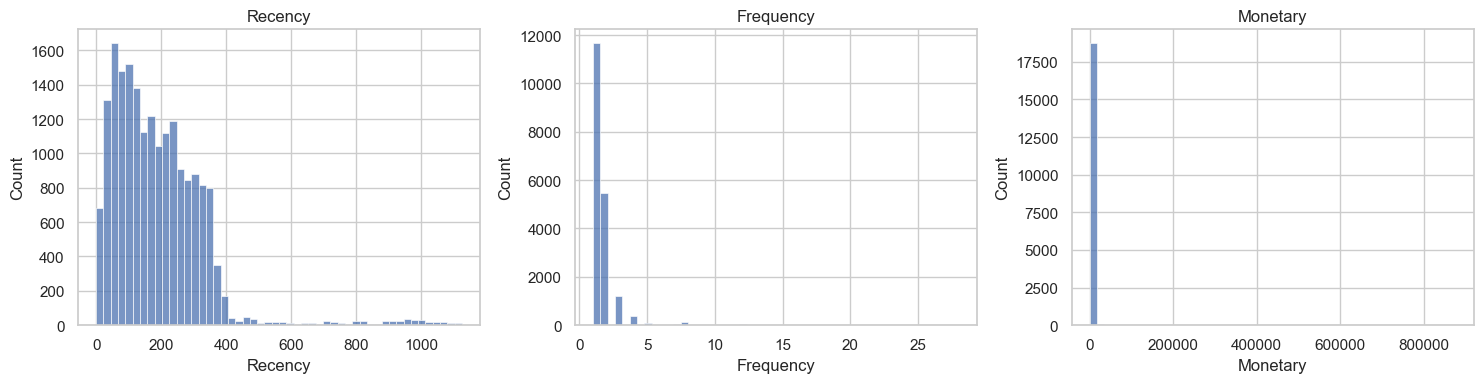

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(['Recency', 'Frequency', 'Monetary']):
    sns.histplot(rfm[col], bins=50, ax=ax[i])
    ax[i].set_title(col)
plt.tight_layout(); plt.show()

## 3. Scale features and choose k (elbow method)

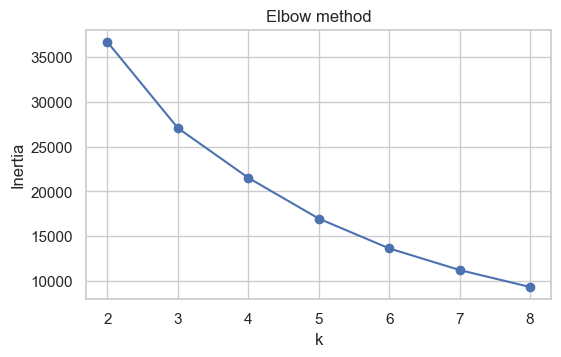

In [4]:
X = rfm[['Recency', 'Frequency', 'Monetary']].copy()
X['Frequency'] = np.log1p(X['Frequency'])
X['Monetary']  = np.log1p(X['Monetary'])
Xs = StandardScaler().fit_transform(X)

inertia = {k: KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xs).inertia_
           for k in range(2, 9)}
plt.figure(figsize=(6, 3.5))
plt.plot(list(inertia.keys()), list(inertia.values()), marker='o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow method'); plt.show()

## 4. Fit KMeans (k=4) and name the segments
We rank cluster centroids to translate math into business labels:
- best R+F+M -> **VIP / Champions**
- good F+M but high recency -> **At Risk** (were valuable, going quiet)
- recent but low F/M -> **New / Promising**
- old, low everything -> **Hibernating**

In [5]:
km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Xs)
rfm['Cluster'] = km.labels_

prof = rfm.groupby('Cluster').agg(
    Customers=('CustomerID', 'count'),
    AvgRecency=('Recency', 'mean'),
    AvgFrequency=('Frequency', 'mean'),
    AvgMonetary=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')).round(0)

# score clusters: low recency good, high freq/monetary good
score = (-prof['AvgRecency'].rank() + prof['AvgFrequency'].rank() + prof['AvgMonetary'].rank())
order = score.sort_values(ascending=False).index.tolist()
names = {}
names[order[0]] = 'VIP'
# among the rest: highest monetary -> At Risk, lowest recency -> New, remainder -> Hibernating
rest = prof.drop(order[0])
at_risk = rest['AvgMonetary'].idxmax(); names[at_risk] = 'At Risk'
rest = rest.drop(at_risk)
new = rest['AvgRecency'].idxmin(); names[new] = 'New / Promising'
names[rest.drop(new).index[0]] = 'Hibernating'

rfm['Segment'] = rfm['Cluster'].map(names)
prof['Segment'] = prof.index.map(names)
prof['RevenueSharePct'] = (100 * prof['TotalRevenue'] / prof['TotalRevenue'].sum()).round(1)
prof.sort_values('RevenueSharePct', ascending=False)

,Customers,AvgRecency,AvgFrequency,AvgMonetary,TotalRevenue,Segment,RevenueSharePct
Cluster,,,,,,,
3,6032,163.0,3.0,16280.0,98198168.0,VIP,89.4
2,471,849.0,1.0,12602.0,5935347.0,At Risk,5.4
1,3750,190.0,1.0,1388.0,5203596.0,Hibernating,4.7
0,8866,174.0,1.0,57.0,509271.0,New / Promising,0.5


                 Customers  AvgRecencyDays  AvgOrders  AvgSpend  TotalRevenue  RevenueSharePct  PctOfCustomers
Segment                                                                                                       
VIP                   6032           163.0        3.0   16280.0    98198168.0             89.4            31.5
At Risk                471           849.0        1.0   12602.0     5935347.0              5.4             2.5
Hibernating           3750           190.0        1.0    1388.0     5203596.0              4.7            19.6
New / Promising       8866           174.0        1.0      57.0      509271.0              0.5            46.4


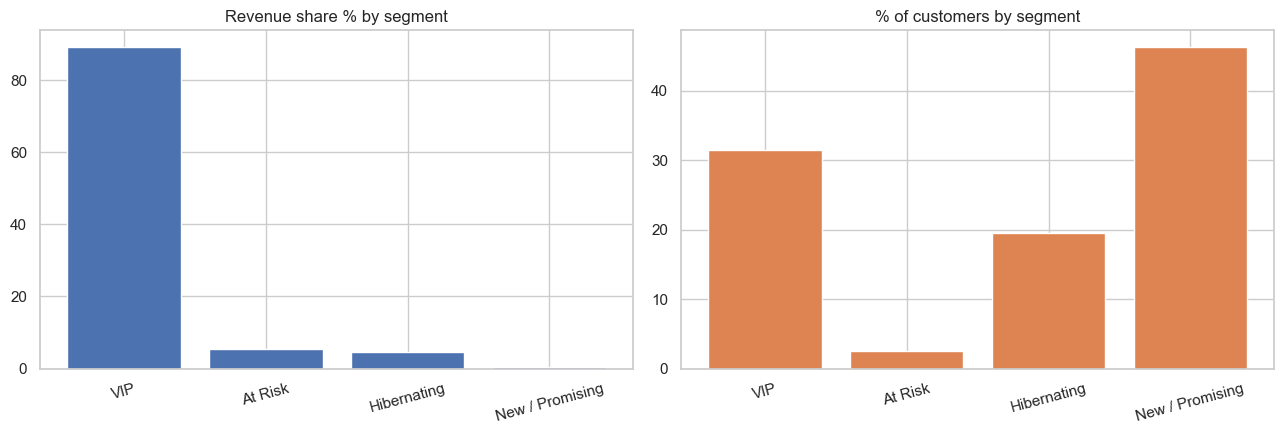

In [6]:
seg = rfm.groupby('Segment').agg(
    Customers=('CustomerID', 'count'),
    AvgRecencyDays=('Recency', 'mean'),
    AvgOrders=('Frequency', 'mean'),
    AvgSpend=('Monetary', 'mean'),
    TotalRevenue=('Monetary', 'sum')).round(0)
seg['RevenueSharePct'] = (100 * seg['TotalRevenue'] / seg['TotalRevenue'].sum()).round(1)
seg['PctOfCustomers'] = (100 * seg['Customers'] / seg['Customers'].sum()).round(1)
print(seg.sort_values('RevenueSharePct', ascending=False).to_string())

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
s = seg.sort_values('RevenueSharePct', ascending=False)
ax[0].bar(s.index, s['RevenueSharePct'], color='#4C72B0')
ax[0].set_title('Revenue share % by segment'); ax[0].tick_params(axis='x', rotation=15)
ax[1].bar(s.index, s['PctOfCustomers'], color='#DD8452')
ax[1].set_title('% of customers by segment'); ax[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()

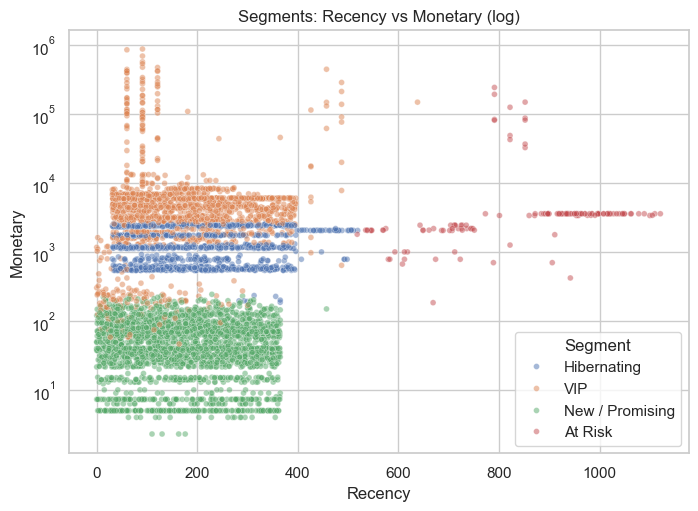

In [7]:
plt.figure(figsize=(8, 5.5))
sample = rfm.sample(min(6000, len(rfm)), random_state=1)
sns.scatterplot(data=sample, x='Recency', y='Monetary', hue='Segment', alpha=0.5, s=18)
plt.yscale('log'); plt.title('Segments: Recency vs Monetary (log)')
plt.show()

## 5. Write segments back to SQL (for Power BI)
Creates table `dbo.CustomerSegments` — Power BI will join it to the customer dimension.

In [8]:
cur = cn.cursor()
cur.execute("IF OBJECT_ID('dbo.CustomerSegments','U') IS NOT NULL DROP TABLE dbo.CustomerSegments")
cur.execute("""CREATE TABLE dbo.CustomerSegments (
    CustomerID INT PRIMARY KEY, CustomerKind NVARCHAR(20),
    Recency INT, Frequency INT, Monetary DECIMAL(12,2), Segment NVARCHAR(30))""")
cur.fast_executemany = True
cur.executemany(
    "INSERT INTO dbo.CustomerSegments VALUES (?,?,?,?,?,?)",
    rfm[['CustomerID','CustomerKind','Recency','Frequency','Monetary','Segment']]
       .astype(object).values.tolist())
cn.commit()
print('rows written:', pd.read_sql('SELECT COUNT(*) n FROM dbo.CustomerSegments', cn).n[0])

rows written: 19119


## Business takeaways
*(filled after inspecting the run — see printed tables above)*
1. Revenue is concentrated in the VIP segment — protect it (account management, loyalty).
2. **At Risk** = previously valuable customers going quiet → re-activation campaign at month 10-12 (matches the 345-day median repurchase window from SQL analysis).
3. **New / Promising** = the post-2013 online accessory buyers → cross-sell high-margin accessories (62% margin Tires & Tubes) to lift their value.
4. Hibernating: lowest priority — cheap email-only touch.